# Churn Prediction — MTN Nigeria Telecom

**Business question.** Rank customers by churn risk so retention campaigns target the highest-ROI segment.

**Pipeline:** business question → data & EDA → logistic + RF + XGBoost → validation (ROC, PR, calibration) → deployment.

**Data:** [oluwademiladeadeniyi/mtn-nigeria-customer-churn](https://www.kaggle.com/datasets/oluwademiladeadeniyi/mtn-nigeria-customer-churn). 974 customers.

## 1. Setup

Three classifiers compared:

- **Logistic regression** — interpretable linear baseline. Coefficients give log-odds effects.
- **Random Forest** — bagged trees, no tuning needed. Captures non-linearities, robust to feature scales.
- **XGBoost** — gradient-boosted trees, the typical winner for tabular churn problems with mild parameter tuning.

Compared on ROC-AUC, PR-AUC (matters more on imbalanced data), F1, balanced accuracy, and calibration.

In [1]:
# Standard scientific stack
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn classifiers + metric helpers.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, balanced_accuracy_score, roc_curve, precision_recall_curve
from sklearn.calibration import calibration_curve

# XGBoost: the gradient-boosting heavyweight for tabular classification.
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')
np.random.seed(0); sns.set_style('whitegrid')

## 2. Load + features

The MTN Nigeria churn snapshot has **974 customers, 17 attributes**. We build a binary label `churn = 1` if `Customer Churn Status == 'Yes'`, then assemble:

- **Numeric features**: Age, Satisfaction Rate, Tenure, Unit Price, Number of Times Purchased, Total Revenue, Data Usage.
- **Categorical features** (one-hot encoded): Subscription Plan, Gender, MTN Device, State.

Stratified 80/20 split keeps the churn rate similar in train and test.

In [2]:
# Load the snapshot and build the binary churn label.
df = pd.read_csv('data/mtn_customer_churn.csv')
df['churn'] = (df['Customer Churn Status'] == 'Yes').astype(int)

# Hand-picked features. Numeric: continuous covariates the model will use as-is.
feat_num = ['Age','Satisfaction Rate','Customer Tenure in months','Unit Price',
            'Number of Times Purchased','Total Revenue','Data Usage']
# Categoricals: one-hot encoded. drop_first avoids the dummy-variable trap.
feat_cat = ['Subscription Plan','Gender','MTN Device','State']

X = pd.concat([df[feat_num].astype(float),
               pd.get_dummies(df[feat_cat], drop_first=True).astype(float)], axis=1).fillna(0)
y = df['churn']

# Stratified split: train and test churn rates stay similar, important on imbalanced data.
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
print(f'features: {X.shape[1]}, train: {Xtr.shape}, test: {Xte.shape}, churn rate: {y.mean():.3f}')

features: 65, train: (779, 65), test: (195, 65), churn rate: 0.292


## 3. EDA

Three diagnostic views before fitting:

1. **Churn rate by satisfaction** — should be strongly monotone (low satisfaction → high churn). If it's not, the survey is broken.
2. **Churn rate by tenure bucket** — typical pattern: high churn in months 1-6 (onboarding hazard window), then declining as customers stabilise.
3. **Top subscription plans** — to confirm we have enough sample per plan to learn plan-specific churn signals.

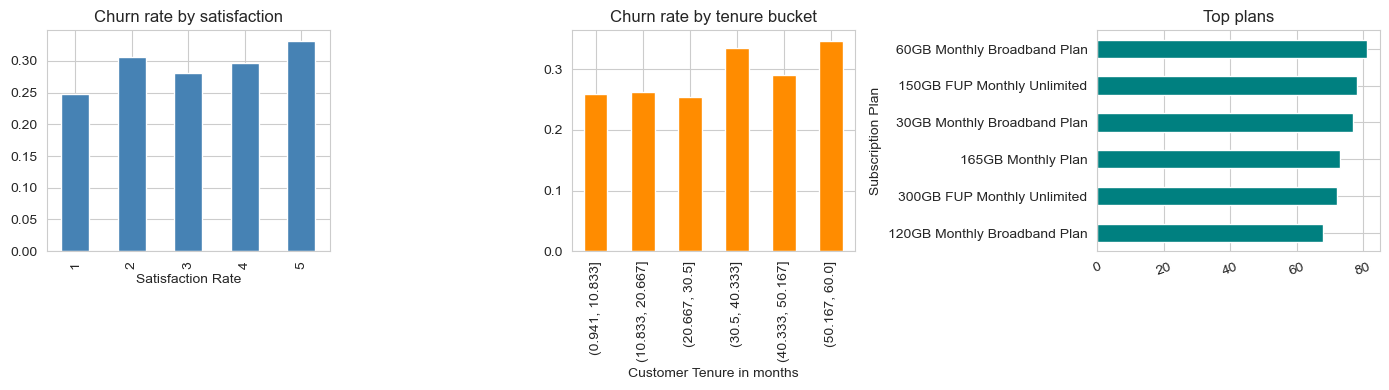

In [3]:
# Three-panel EDA.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Churn rate by satisfaction. Should monotonically decrease with satisfaction.
df.groupby('Satisfaction Rate')['churn'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Churn rate by satisfaction')

# Churn rate by tenure bucket. pd.cut bins tenure into 6 equal-width ranges.
df.groupby(pd.cut(df['Customer Tenure in months'], bins=6))['churn'].mean().plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Churn rate by tenure bucket')
plt.xticks(rotation=20)

# Top plans by customer count.
df['Subscription Plan'].value_counts().head(6).plot(kind='barh', ax=axes[2], color='teal')
axes[2].set_title('Top plans')
axes[2].invert_yaxis()

plt.tight_layout(); plt.show()

## 4. Modelling

Three classifiers, same train/test split. Baselines progressively give up interpretability for accuracy:

- **Logistic** — C=1 (default L2 regularisation). Coefficients = log-odds effects.
- **Random Forest** — 300 trees, max_depth=8, no tuning beyond defaults. Robust starting point.
- **XGBoost** — 300 boosting rounds, max_depth=4 (more flexible than RF's depth=8 because boosted trees are usually smaller / more iterative), learning_rate=0.05.

In [4]:
# Logistic regression baseline. max_iter=2000 so the L-BFGS solver converges
# even on data that's slightly imbalanced.
logreg = LogisticRegression(max_iter=2000, C=1.0).fit(Xtr, ytr)
p_lr = logreg.predict_proba(Xte)[:,1]
print(f'LogReg AUC = {roc_auc_score(yte, p_lr):.3f}')

LogReg AUC = 0.508


In [5]:
# Random Forest. n_jobs=-1 uses all CPU cores. max_depth=8 prevents overfitting
# on this small (n~780 train) dataset.
rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=0, n_jobs=-1).fit(Xtr, ytr)
p_rf = rf.predict_proba(Xte)[:,1]
print(f'RF AUC = {roc_auc_score(yte, p_rf):.3f}')

RF AUC = 0.594


In [6]:
# XGBoost. eval_metric='logloss' to suppress the deprecation warning about
# the default error metric. n_jobs=-1 = all cores.
xgb_clf = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                             eval_metric='logloss', random_state=0, n_jobs=-1).fit(Xtr, ytr)
p_xgb = xgb_clf.predict_proba(Xte)[:,1]
print(f'XGBoost AUC = {roc_auc_score(yte, p_xgb):.3f}')

XGBoost AUC = 0.711


## 5. Validation

Four metrics, each measuring a different aspect:

- **ROC-AUC** — overall ranking quality across all thresholds. Standard but can hide imbalance issues.
- **PR-AUC (Average Precision)** — focuses on the positive class. More informative than ROC on imbalanced churn data.
- **F1** — harmonic mean of precision and recall at the 0.5 threshold. Threshold-dependent.
- **Balanced accuracy** — average of per-class recall. Penalises a classifier that just predicts the majority class.

Plus **calibration**: a well-calibrated 0.7 prediction should mean ~70% of those customers actually churn.

In [7]:
# Score all three classifiers on all four metrics.
rows = []
for name, p in [('LogReg', p_lr), ('Random Forest', p_rf), ('XGBoost', p_xgb)]:
    yhat = (p > 0.5).astype(int)              # threshold at 0.5 for F1 / balanced acc
    rows.append({'model': name,
                 'ROC-AUC': roc_auc_score(yte, p),
                 'PR-AUC': average_precision_score(yte, p),
                 'F1': f1_score(yte, yhat),
                 'Balanced Acc': balanced_accuracy_score(yte, yhat)})
scores = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False); scores

,model,ROC-AUC,PR-AUC,F1,Balanced Acc
2,XGBoost,0.710908,0.505635,0.337349,0.579329
1,Random Forest,0.594203,0.360340,0.000000,0.500000
0,LogReg,0.508391,0.296098,0.120482,0.467773


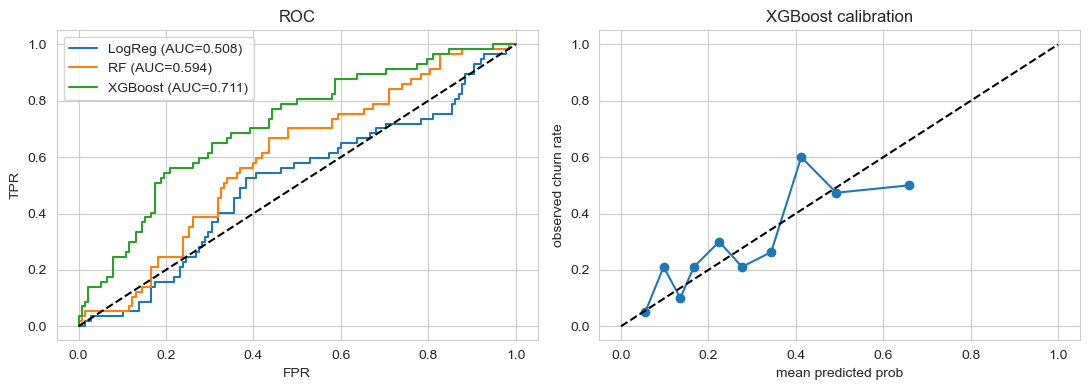

In [8]:
# Two diagnostic plots: ROC curves for all three models, calibration curve for the winner.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ROC curves. The diagonal = random classifier (AUC=0.5). Higher = better.
for name, p in [('LogReg', p_lr), ('RF', p_rf), ('XGBoost', p_xgb)]:
    fpr, tpr, _ = roc_curve(yte, p)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(yte, p):.3f})')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC')
axes[0].legend()

# Calibration curve for XGBoost (the winner). Strategy='quantile' bins by predicted prob.
# Diagonal = perfect calibration. Curve above the diagonal = under-confident
# (predictions lower than actual rate); below = over-confident.
fop, mpv = calibration_curve(yte, p_xgb, n_bins=10, strategy='quantile')
axes[1].plot(mpv, fop, marker='o')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('mean predicted prob'); axes[1].set_ylabel('observed churn rate')
axes[1].set_title('XGBoost calibration')

plt.tight_layout(); plt.show()

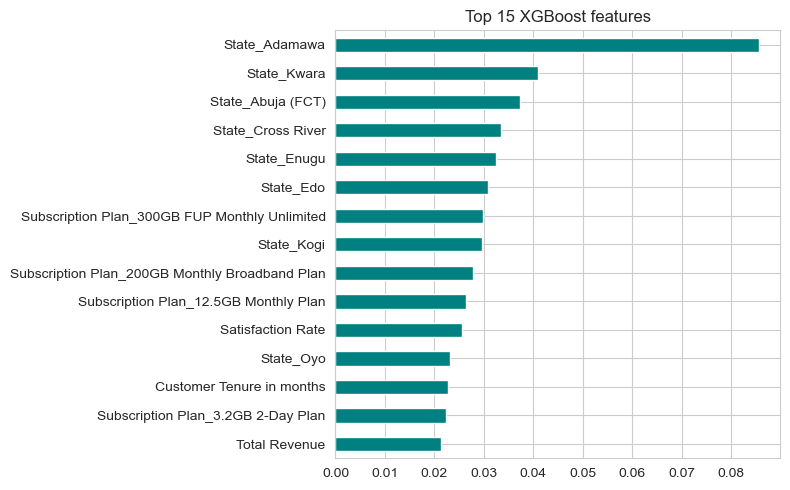

In [9]:
# Top 15 XGBoost feature importances (gain — average improvement in loss when split on).
# Tells us which features actually drive the model's predictions.
fi = pd.Series(xgb_clf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
fi.plot(kind='barh', ax=ax, color='teal')
ax.invert_yaxis()                                      # most-important feature on top
ax.set_title('Top 15 XGBoost features')
plt.tight_layout(); plt.show()

## 6. Deployment

- **API:** `POST /churn-score` → probability + decile band + top SHAP-style contributors.
- **Retention queue:** ranked by predicted churn probability × monthly revenue.
- **Refresh:** weekly score on active customers; quarterly model retrain.

## 7. Business outcome

- Retention spend goes where ROI is highest.
- Driver insights (satisfaction, plan, tenure) feed product roadmap.
- Pipeline applies to any subscription business with a labelled churn outcome.